In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("C:\Documents\HPDC_1000_rows_11_columns_FIXED.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 11


In [6]:
df.head()

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type,quality,defect_type
0,697.5,204.0,3.28,785.0,537.4,0.0454,7.50,-0.673,AlSi9Cu3,DEFECT,Porosity
1,680.0,200.8,2.63,752.0,658.2,0.0452,8.21,-0.810,AlSi12,OK,No_Defect
2,678.0,178.2,3.22,807.8,521.0,0.0436,8.54,-0.756,AlSi12,DEFECT,Porosity
3,694.8,208.6,2.94,760.6,661.8,0.0516,8.29,-0.834,AlSi9Cu3,OK,No_Defect
4,687.8,198.6,2.40,633.4,596.9,0.0410,8.97,-0.849,AlSi10Mg,OK,No_Defect


In [7]:
print(df.columns.tolist())

['melt_temp_C', 'die_temp_C', 'injection_speed_mps', 'injection_pressure_bar', 'intensification_pressure_bar', 'filling_time_s', 'cooling_time_s', 'vacuum_pressure_bar', 'alloy_type', 'quality', 'defect_type']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   melt_temp_C                   1000 non-null   float64
 1   die_temp_C                    1000 non-null   float64
 2   injection_speed_mps           1000 non-null   float64
 3   injection_pressure_bar        1000 non-null   float64
 4   intensification_pressure_bar  1000 non-null   float64
 5   filling_time_s                1000 non-null   float64
 6   cooling_time_s                1000 non-null   float64
 7   vacuum_pressure_bar           1000 non-null   float64
 8   alloy_type                    1000 non-null   str    
 9   quality                       1000 non-null   str    
 10  defect_type                   1000 non-null   str    
dtypes: float64(8), str(3)
memory usage: 105.2 KB


In [9]:
print(df.isnull().sum())

melt_temp_C                     0
die_temp_C                      0
injection_speed_mps             0
injection_pressure_bar          0
intensification_pressure_bar    0
filling_time_s                  0
cooling_time_s                  0
vacuum_pressure_bar             0
alloy_type                      0
quality                         0
defect_type                     0
dtype: int64


In [10]:
print(df["quality"].value_counts())

quality
OK        760
DEFECT    240
Name: count, dtype: int64


In [11]:
print(
    df["quality"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

quality
OK        76.0
DEFECT    24.0
Name: proportion, dtype: float64


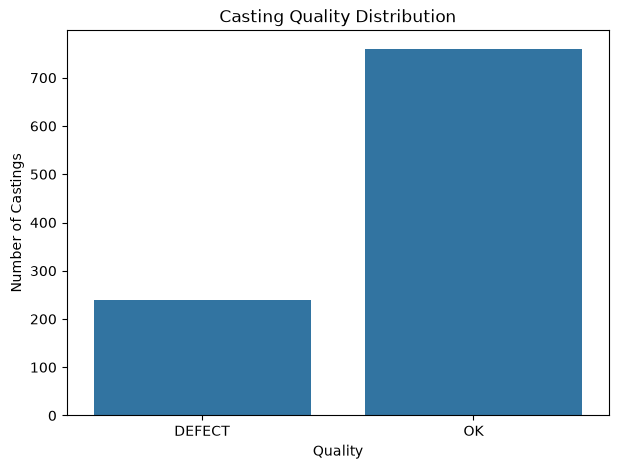

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Casting Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Number of Castings")
plt.show()

In [13]:
print(df["defect_type"].value_counts())

defect_type
No_Defect         760
Cold_Shut          80
Porosity           77
Flash              50
Surface_Defect     33
Name: count, dtype: int64


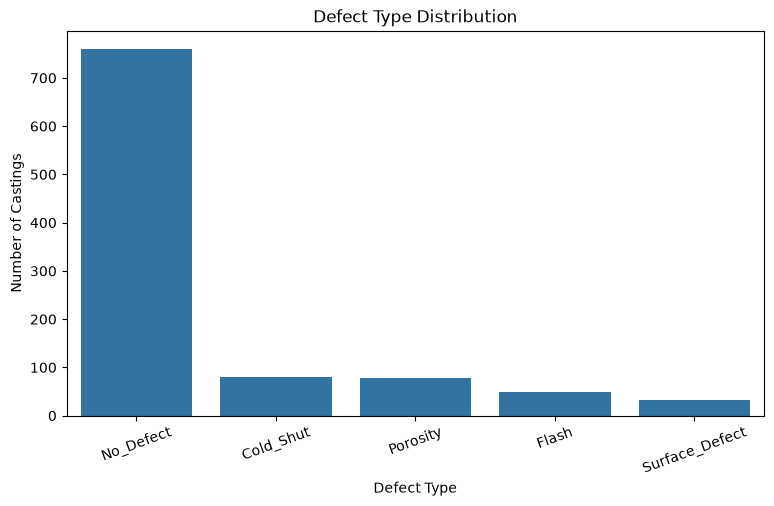

In [14]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="defect_type",
    order=df["defect_type"].value_counts().index
)

plt.title("Defect Type Distribution")
plt.xlabel("Defect Type")
plt.ylabel("Number of Castings")
plt.xticks(rotation=20)

plt.show()

In [15]:
df.describe()

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,679.817300,194.664200,2.732410,747.572500,641.646200,0.047086,8.273620,-0.830826
std,10.329092,15.038147,0.291407,59.383487,56.590146,0.007609,0.494139,0.068870
min,650.000000,145.000000,1.650000,520.000000,450.000000,0.028000,7.120000,-0.970000
25%,673.075000,185.700000,2.580000,719.575000,613.350000,0.042775,7.970000,-0.870000
50%,680.600000,195.450000,2.740000,748.600000,645.550000,0.046800,8.260000,-0.842000
75%,686.825000,204.325000,2.890000,780.825000,676.125000,0.050800,8.550000,-0.812000
max,708.500000,235.000000,3.500000,950.000000,820.000000,0.076500,10.410000,-0.514000


In [16]:
print(df["alloy_type"].value_counts())

alloy_type
AlSi9Cu3    545
AlSi10Mg    307
AlSi12      148
Name: count, dtype: int64


In [17]:
pd.crosstab(
    df["alloy_type"],
    df["quality"],
    normalize="index"
).round(3)

quality,DEFECT,OK
alloy_type,,
AlSi10Mg,0.257,0.743
AlSi12,0.203,0.797
AlSi9Cu3,0.240,0.760


In [18]:
features = [
    "melt_temp_C",
    "die_temp_C",
    "injection_speed_mps",
    "injection_pressure_bar",
    "intensification_pressure_bar",
    "filling_time_s",
    "cooling_time_s",
    "vacuum_pressure_bar",
    "alloy_type"
]

X = df[features].copy()

print("Input features:")
print(X.columns.tolist())

Input features:
['melt_temp_C', 'die_temp_C', 'injection_speed_mps', 'injection_pressure_bar', 'intensification_pressure_bar', 'filling_time_s', 'cooling_time_s', 'vacuum_pressure_bar', 'alloy_type']


In [19]:
y = df["quality"].map({
    "OK": 0,
    "DEFECT": 1
})

print(y.value_counts())

quality
0    760
1    240
Name: count, dtype: int64


In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X rows:")
display(X.head())

print("\nFirst 5 y values:")
display(y.head())

X shape: (1000, 9)
y shape: (1000,)

First 5 X rows:


,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type
0,697.5,204.0,3.28,785.0,537.4,0.0454,7.50,-0.673,AlSi9Cu3
1,680.0,200.8,2.63,752.0,658.2,0.0452,8.21,-0.810,AlSi12
2,678.0,178.2,3.22,807.8,521.0,0.0436,8.54,-0.756,AlSi12
3,694.8,208.6,2.94,760.6,661.8,0.0516,8.29,-0.834,AlSi9Cu3
4,687.8,198.6,2.40,633.4,596.9,0.0410,8.97,-0.849,AlSi10Mg



First 5 y values:


0    1
1    0
2    1
3    0
4    0
Name: quality, dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 800
Testing samples : 200


In [22]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
quality
0    608
1    192
Name: count, dtype: int64

Testing distribution:
quality
0    152
1     48
Name: count, dtype: int64


In [23]:
numeric_features = [
    "melt_temp_C",
    "die_temp_C",
    "injection_speed_mps",
    "injection_pressure_bar",
    "intensification_pressure_bar",
    "filling_time_s",
    "cooling_time_s",
    "vacuum_pressure_bar"
]

categorical_features = [
    "alloy_type"
]

In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest created successfully!")

Random Forest created successfully!


In [26]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [27]:
rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [28]:
y_pred = rf_pipeline.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1]


In [29]:
y_probability = rf_pipeline.predict_proba(X_test)[:, 1]

print(y_probability[:20])

[0.21       0.00333333 0.         0.         0.34333333 0.01666667
 0.98666667 0.00333333 0.00333333 0.         0.         0.00333333
 0.90666667 0.05333333 0.94333333 0.00333333 0.92666667 0.28
 0.01333333 0.93666667]


In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.995
Accuracy (%): 99.5 %


In [31]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 1.0


In [32]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))

Recall: 0.9792


In [33]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 4))

F1 Score: 0.9895


In [34]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9997


In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["OK", "DEFECT"]
    )
)

              precision    recall  f1-score   support

          OK       0.99      1.00      1.00       152
      DEFECT       1.00      0.98      0.99        48

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[152   0]
 [  1  47]]


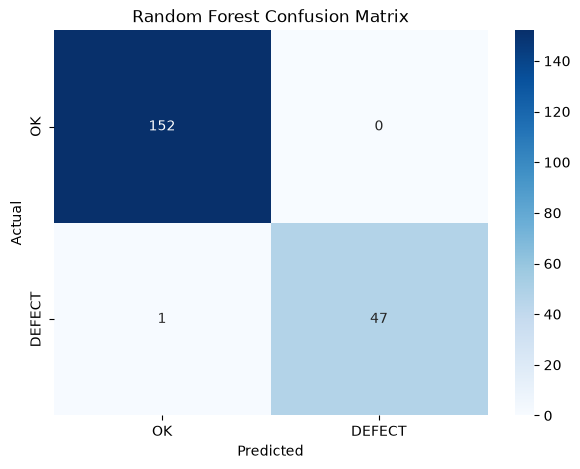

In [37]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["OK", "DEFECT"],
    yticklabels=["OK", "DEFECT"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [38]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

train_accuracy = accuracy_score(y_train, rf_train_pred)
test_accuracy = accuracy_score(y_test, rf_test_pred)

train_f1 = f1_score(y_train, rf_train_pred)
test_f1 = f1_score(y_test, rf_test_pred)

print("===== RANDOM FOREST =====")

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))

print("Train F1:", round(train_f1, 4))
print("Test F1 :", round(test_f1, 4))

print("\nAccuracy Gap:", round(train_accuracy - test_accuracy, 4))
print("F1 Gap:", round(train_f1 - test_f1, 4))

===== RANDOM FOREST =====
Train Accuracy: 1.0
Test Accuracy : 0.995
Train F1: 1.0
Test F1 : 0.9895

Accuracy Gap: 0.005
F1 Gap: 0.0105


In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_f1 = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("5-Fold F1 Scores:")
print(cv_f1)

print("\nMean F1:", round(cv_f1.mean(), 4))
print("Std F1 :", round(cv_f1.std(), 4))

5-Fold F1 Scores:
[0.94845361 0.96969697 0.96842105 0.98947368 0.96842105]

Mean F1: 0.9689
Std F1 : 0.013


In [40]:
cv_accuracy = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold Accuracy Scores:")
print(cv_accuracy)

print("\nMean Accuracy:", round(cv_accuracy.mean(), 4))
print("Std Accuracy :", round(cv_accuracy.std(), 4))

5-Fold Accuracy Scores:
[0.975 0.985 0.985 0.995 0.985]

Mean Accuracy: 0.985
Std Accuracy : 0.0063


In [41]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFeatures:")
for feature in feature_names:
    print(feature)

Number of processed features: 11

Features:
num__melt_temp_C
num__die_temp_C
num__injection_speed_mps
num__injection_pressure_bar
num__intensification_pressure_bar
num__filling_time_s
num__cooling_time_s
num__vacuum_pressure_bar
cat__alloy_type_AlSi10Mg
cat__alloy_type_AlSi12
cat__alloy_type_AlSi9Cu3


In [42]:
importances = rf_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df

,Feature,Importance
0,num__vacuum_pressure_bar,0.187972
1,num__injection_speed_mps,0.161261
2,num__intensification_pressure_bar,0.154021
3,num__filling_time_s,0.147210
4,num__injection_pressure_bar,0.124466
5,num__cooling_time_s,0.092913
6,num__die_temp_C,0.080707
7,num__melt_temp_C,0.046215
8,cat__alloy_type_AlSi10Mg,0.001913
9,cat__alloy_type_AlSi9Cu3,0.001850


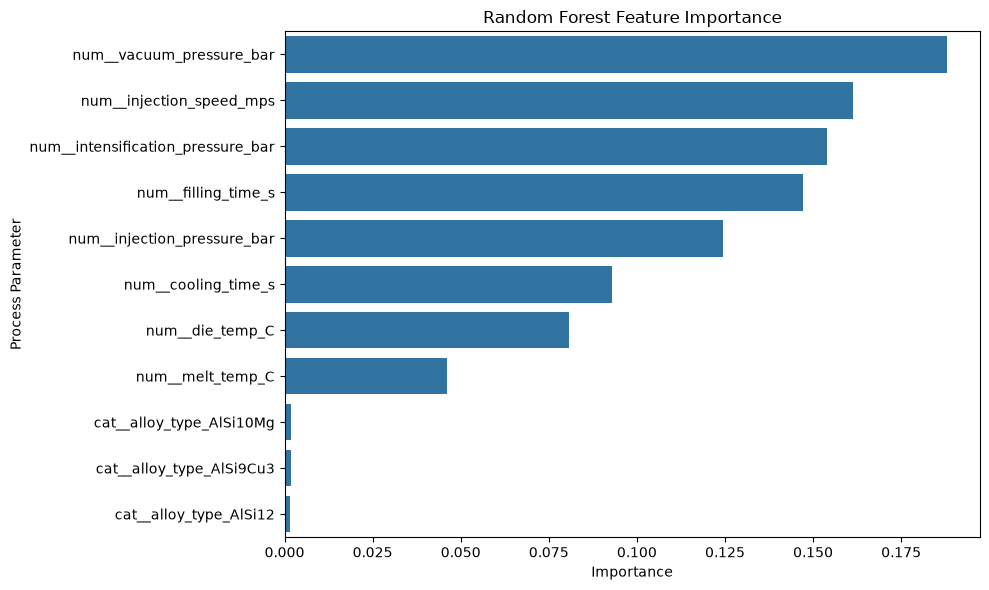

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Process Parameter")

plt.tight_layout()
plt.show()

In [44]:
top_5 = importance_df.head(5)

print("Top 5 Important Features:\n")

for i, row in top_5.iterrows():
    print(
        f"{i+1}. {row['Feature']} "
        f"→ {row['Importance']:.4f}"
    )

Top 5 Important Features:

1. num__vacuum_pressure_bar → 0.1880
2. num__injection_speed_mps → 0.1613
3. num__intensification_pressure_bar → 0.1540
4. num__filling_time_s → 0.1472
5. num__injection_pressure_bar → 0.1245


In [45]:
final_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "CV Mean Accuracy",
        "CV Mean F1"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_accuracy.mean(),
        cv_f1.mean()
    ]
})

final_results["Score (%)"] = (
    final_results["Score"] * 100
).round(2)

final_results

,Metric,Score,Score (%)
0,Test Accuracy,0.995000,99.50
1,Test Precision,1.000000,100.00
2,Test Recall,0.979167,97.92
3,Test F1,0.989474,98.95
4,Test ROC-AUC,0.999726,99.97
5,CV Mean Accuracy,0.985000,98.50
6,CV Mean F1,0.968893,96.89


In [46]:
print("=" * 50)
print("       HPDC RANDOM FOREST MODEL RESULTS")
print("=" * 50)

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Test Precision: {precision * 100:.2f}%")
print(f"Test Recall   : {recall * 100:.2f}%")
print(f"Test F1 Score : {f1 * 100:.2f}%")
print(f"Test ROC-AUC  : {roc_auc * 100:.2f}%")

print("\n5-Fold Cross Validation")
print(f"Mean Accuracy : {cv_accuracy.mean() * 100:.2f}%")
print(f"Mean F1 Score : {cv_f1.mean() * 100:.2f}%")
print(f"F1 Std Dev    : {cv_f1.std() * 100:.2f}%")

print("=" * 50)

       HPDC RANDOM FOREST MODEL RESULTS
Test Accuracy : 99.50%
Test Precision: 100.00%
Test Recall   : 97.92%
Test F1 Score : 98.95%
Test ROC-AUC  : 99.97%

5-Fold Cross Validation
Mean Accuracy : 98.50%
Mean F1 Score : 96.89%
F1 Std Dev    : 1.30%


In [47]:
import joblib

joblib.dump(
    rf_pipeline,
    "HPDC_RandomForest_Final.pkl"
)

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


In [48]:
loaded_model = joblib.load(
    "HPDC_RandomForest_Final.pkl"
)

print("Final model loaded successfully!")

Final model loaded successfully!


In [63]:
new_casting = pd.DataFrame({
    "melt_temp_C": [680],
    "die_temp_C": [190],
    "injection_speed_mps": [2.50],
    "injection_pressure_bar": [720],
    "intensification_pressure_bar": [620],
    "filling_time_s": [0.045],
    "cooling_time_s": [8.5],
    "vacuum_pressure_bar": [-0.75],
    "alloy_type": ["AlSi9Cu3"]
})

new_casting

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type
0,680,190,2.5,720,620,0.045,8.5,-0.75,AlSi9Cu3


In [64]:
prediction = loaded_model.predict(new_casting)[0]

if prediction == 0:
    print("Predicted Quality: OK")
else:
    print("Predicted Quality: DEFECT")

Predicted Quality: OK


In [65]:
probability = loaded_model.predict_proba(
    new_casting
)[0][1]

print(
    f"Defect Probability: {probability * 100:.2f}%"
)

Defect Probability: 48.67%


In [66]:
if probability < 0.30:
    risk = "LOW"
elif probability < 0.60:
    risk = "MEDIUM"
else:
    risk = "HIGH"

print("Risk Level:", risk)

Risk Level: MEDIUM


In [67]:
def predict_casting(
    melt_temp,
    die_temp,
    injection_speed,
    injection_pressure,
    intensification_pressure,
    filling_time,
    cooling_time,
    vacuum_pressure,
    alloy_type
):
    
    input_data = pd.DataFrame({
        "melt_temp_C": [melt_temp],
        "die_temp_C": [die_temp],
        "injection_speed_mps": [injection_speed],
        "injection_pressure_bar": [injection_pressure],
        "intensification_pressure_bar": [intensification_pressure],
        "filling_time_s": [filling_time],
        "cooling_time_s": [cooling_time],
        "vacuum_pressure_bar": [vacuum_pressure],
        "alloy_type": [alloy_type]
    })
    
    prediction = loaded_model.predict(input_data)[0]
    
    probability = loaded_model.predict_proba(
        input_data
    )[0][1]
    
    quality = "DEFECT" if prediction == 1 else "OK"
    
    if probability < 0.30:
        risk = "LOW"
    elif probability < 0.60:
        risk = "MEDIUM"
    else:
        risk = "HIGH"
    
    return {
        "Predicted Quality": quality,
        "Defect Probability (%)": round(
            probability * 100, 2
        ),
        "Risk Level": risk
    }

In [68]:
result = predict_casting(
    melt_temp=680,
    die_temp=190,
    injection_speed=2.50,
    injection_pressure=720,
    intensification_pressure=620,
    filling_time=0.045,
    cooling_time=8.5,
    vacuum_pressure=-0.75,
    alloy_type="AlSi9Cu3"
)

print(result)

{'Predicted Quality': 'OK', 'Defect Probability (%)': np.float64(48.67), 'Risk Level': 'MEDIUM'}


In [69]:
test_cases = [
    {
        "name": "Normal Process",
        "melt_temp": 680,
        "die_temp": 190,
        "injection_speed": 2.50,
        "injection_pressure": 720,
        "intensification_pressure": 620,
        "filling_time": 0.045,
        "cooling_time": 8.5,
        "vacuum_pressure": -0.75,
        "alloy_type": "AlSi9Cu3"
    },
    {
        "name": "High Temperature",
        "melt_temp": 708,
        "die_temp": 225,
        "injection_speed": 3.30,
        "injection_pressure": 900,
        "intensification_pressure": 780,
        "filling_time": 0.070,
        "cooling_time": 10.0,
        "vacuum_pressure": -0.55,
        "alloy_type": "AlSi9Cu3"
    },
    {
        "name": "Low Pressure",
        "melt_temp": 655,
        "die_temp": 155,
        "injection_speed": 1.80,
        "injection_pressure": 550,
        "intensification_pressure": 470,
        "filling_time": 0.070,
        "cooling_time": 7.5,
        "vacuum_pressure": -0.60,
        "alloy_type": "AlSi12"
    }
]

for case in test_cases:
    
    name = case.pop("name")
    
    result = predict_casting(**case)
    
    print("\n" + "=" * 45)
    print(name)
    print("=" * 45)
    print(result)


Normal Process
{'Predicted Quality': 'OK', 'Defect Probability (%)': np.float64(48.67), 'Risk Level': 'MEDIUM'}

High Temperature
{'Predicted Quality': 'DEFECT', 'Defect Probability (%)': np.float64(79.0), 'Risk Level': 'HIGH'}

Low Pressure
{'Predicted Quality': 'DEFECT', 'Defect Probability (%)': np.float64(98.33), 'Risk Level': 'HIGH'}


In [70]:
parameter_ranges = {
    "melt_temp_C": (
        df["melt_temp_C"].min(),
        df["melt_temp_C"].max()
    ),
    
    "die_temp_C": (
        df["die_temp_C"].min(),
        df["die_temp_C"].max()
    ),
    
    "injection_speed_mps": (
        df["injection_speed_mps"].min(),
        df["injection_speed_mps"].max()
    ),
    
    "injection_pressure_bar": (
        df["injection_pressure_bar"].min(),
        df["injection_pressure_bar"].max()
    ),
    
    "intensification_pressure_bar": (
        df["intensification_pressure_bar"].min(),
        df["intensification_pressure_bar"].max()
    ),
    
    "filling_time_s": (
        df["filling_time_s"].min(),
        df["filling_time_s"].max()
    ),
    
    "cooling_time_s": (
        df["cooling_time_s"].min(),
        df["cooling_time_s"].max()
    ),
    
    "vacuum_pressure_bar": (
        df["vacuum_pressure_bar"].min(),
        df["vacuum_pressure_bar"].max()
    )
}

parameter_ranges

{'melt_temp_C': (np.float64(650.0), np.float64(708.5)),
 'die_temp_C': (np.float64(145.0), np.float64(235.0)),
 'injection_speed_mps': (np.float64(1.65), np.float64(3.5)),
 'injection_pressure_bar': (np.float64(520.0), np.float64(950.0)),
 'intensification_pressure_bar': (np.float64(450.0), np.float64(820.0)),
 'filling_time_s': (np.float64(0.028), np.float64(0.0765)),
 'cooling_time_s': (np.float64(7.12), np.float64(10.41)),
 'vacuum_pressure_bar': (np.float64(-0.97), np.float64(-0.514))}

In [71]:
current_process = {
    "melt_temp_C": 680,
    "die_temp_C": 190,
    "injection_speed_mps": 2.50,
    "injection_pressure_bar": 720,
    "intensification_pressure_bar": 620,
    "filling_time_s": 0.045,
    "cooling_time_s": 8.5,
    "vacuum_pressure_bar": -0.75,
    "alloy_type": "AlSi9Cu3"
}

current_process

{'melt_temp_C': 680,
 'die_temp_C': 190,
 'injection_speed_mps': 2.5,
 'injection_pressure_bar': 720,
 'intensification_pressure_bar': 620,
 'filling_time_s': 0.045,
 'cooling_time_s': 8.5,
 'vacuum_pressure_bar': -0.75,
 'alloy_type': 'AlSi9Cu3'}

In [72]:
current_df = pd.DataFrame([current_process])

current_prediction = loaded_model.predict(
    current_df
)[0]

current_probability = loaded_model.predict_proba(
    current_df
)[0][1]

current_quality = (
    "DEFECT" if current_prediction == 1 else "OK"
)

print("CURRENT PROCESS")
print("-" * 35)

print("Quality:", current_quality)
print(
    f"Defect Probability: "
    f"{current_probability * 100:.2f}%"
)

CURRENT PROCESS
-----------------------------------
Quality: OK
Defect Probability: 48.67%


In [73]:
import numpy as np

np.random.seed(42)

n_candidates = 5000

candidates = pd.DataFrame()

for parameter, (minimum, maximum) in parameter_ranges.items():
    
    current_value = current_process[parameter]
    
    # Generate values around current operating condition
    values = np.random.normal(
        loc=current_value,
        scale=(maximum - minimum) * 0.08,
        size=n_candidates
    )
    
    # Keep values inside observed dataset range
    values = np.clip(
        values,
        minimum,
        maximum
    )
    
    candidates[parameter] = values

# Add alloy
candidates["alloy_type"] = current_process["alloy_type"]

print("Generated candidate settings:", len(candidates))

candidates.head()

Generated candidate settings: 5000


,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type
0,682.324622,186.948930,2.399583,715.066241,630.309273,0.045663,7.978713,-0.716654,AlSi9Cu3
1,679.352923,186.735418,2.454786,718.876637,628.386378,0.045048,8.222328,-0.690739,AlSi9Cu3
2,683.031182,177.071369,2.411588,722.211744,592.279013,0.043327,8.345494,-0.737396,AlSi9Cu3
3,687.127780,187.623351,2.516342,752.572034,637.155693,0.044990,8.539393,-0.759307,AlSi9Cu3
4,678.904162,195.276369,2.677182,694.295725,575.893553,0.046904,8.769560,-0.788914,AlSi9Cu3


In [74]:
candidate_probabilities = loaded_model.predict_proba(
    candidates
)[:, 1]

candidates["defect_probability"] = candidate_probabilities

print("Candidate predictions completed!")

Candidate predictions completed!


In [75]:
best_candidates = candidates.sort_values(
    by="defect_probability",
    ascending=True
).head(10)

best_candidates

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type,defect_probability
4895,679.953926,184.396178,2.587059,681.683753,634.400371,0.048744,8.209058,-0.801654,AlSi9Cu3,0.0
1010,686.165404,189.577213,2.530588,772.129648,626.647883,0.048899,8.110344,-0.791061,AlSi9Cu3,0.0
641,687.811021,185.971267,2.411125,736.489787,632.577115,0.049859,8.139655,-0.823271,AlSi9Cu3,0.0
4288,687.062733,190.144872,2.471276,748.556048,632.909243,0.043075,8.333045,-0.836349,AlSi9Cu3,0.0
4257,686.666640,182.109730,2.681852,701.498704,672.189303,0.047237,8.149133,-0.805670,AlSi9Cu3,0.0
4269,684.349639,186.875269,2.376244,721.869147,624.487599,0.043635,8.438954,-0.821606,AlSi9Cu3,0.0
1560,679.900001,187.819226,2.525336,749.437295,648.614467,0.046838,7.989485,-0.805776,AlSi9Cu3,0.0
4282,685.425903,183.928252,2.523485,751.176071,634.988923,0.051664,7.971896,-0.800019,AlSi9Cu3,0.0
1756,679.356741,192.492045,2.514064,757.417800,616.543178,0.043819,8.278986,-0.801033,AlSi9Cu3,0.0
1758,687.545462,204.862385,2.561236,737.809594,671.042783,0.052465,8.533359,-0.825842,AlSi9Cu3,0.0


In [76]:
recommendation_df = best_candidates.copy()

for parameter in parameter_ranges.keys():
    
    minimum, maximum = parameter_ranges[parameter]
    
    parameter_range = maximum - minimum
    
    recommendation_df[
        parameter + "_change"
    ] = (
        abs(
            recommendation_df[parameter]
            - current_process[parameter]
        )
        / parameter_range
    )

recommendation_df.head()

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type,defect_probability,melt_temp_C_change,die_temp_C_change,injection_speed_mps_change,injection_pressure_bar_change,intensification_pressure_bar_change,filling_time_s_change,cooling_time_s_change,vacuum_pressure_bar_change
4895,679.953926,184.396178,2.587059,681.683753,634.400371,0.048744,8.209058,-0.801654,AlSi9Cu3,0.0,0.000788,0.062265,0.047059,0.089108,0.038920,0.077192,0.088432,0.113277
1010,686.165404,189.577213,2.530588,772.129648,626.647883,0.048899,8.110344,-0.791061,AlSi9Cu3,0.0,0.105392,0.004698,0.016534,0.121232,0.017967,0.080387,0.118437,0.090047
641,687.811021,185.971267,2.411125,736.489787,632.577115,0.049859,8.139655,-0.823271,AlSi9Cu3,0.0,0.133522,0.044764,0.048041,0.038348,0.033992,0.100182,0.109527,0.160681
4288,687.062733,190.144872,2.471276,748.556048,632.909243,0.043075,8.333045,-0.836349,AlSi9Cu3,0.0,0.120730,0.001610,0.015526,0.066409,0.034890,0.039686,0.050746,0.189363
4257,686.666640,182.109730,2.681852,701.498704,672.189303,0.047237,8.149133,-0.805670,AlSi9Cu3,0.0,0.113960,0.087670,0.098298,0.043026,0.141052,0.046132,0.106646,0.122083


In [77]:
change_columns = [
    parameter + "_change"
    for parameter in parameter_ranges.keys()
]

recommendation_df["change_score"] = (
    recommendation_df[change_columns]
    .mean(axis=1)
)

recommendation_df[
    [
        "defect_probability",
        "change_score"
    ]
].head(10)

,defect_probability,change_score
4895,0.0,0.064630
1010,0.0,0.069336
641,0.0,0.083632
4288,0.0,0.064870
4257,0.0,0.094858
4269,0.0,0.049522
1560,0.0,0.062602
4282,0.0,0.086691
1756,0.0,0.043262
1758,0.0,0.104622


In [78]:
recommendation_df["optimization_score"] = (
    0.70 * recommendation_df["defect_probability"]
    +
    0.30 * recommendation_df["change_score"]
)

recommendation_df = recommendation_df.sort_values(
    by="optimization_score",
    ascending=True
)

recommendation_df.head(10)

,melt_temp_C,die_temp_C,injection_speed_mps,injection_pressure_bar,intensification_pressure_bar,filling_time_s,cooling_time_s,vacuum_pressure_bar,alloy_type,defect_probability,melt_temp_C_change,die_temp_C_change,injection_speed_mps_change,injection_pressure_bar_change,intensification_pressure_bar_change,filling_time_s_change,cooling_time_s_change,vacuum_pressure_bar_change,change_score,optimization_score
1756,679.356741,192.492045,2.514064,757.417800,616.543178,0.043819,8.278986,-0.801033,AlSi9Cu3,0.0,0.010996,0.027689,0.007602,0.087018,0.009343,0.024359,0.067177,0.111914,0.043262,0.012979
4269,684.349639,186.875269,2.376244,721.869147,624.487599,0.043635,8.438954,-0.821606,AlSi9Cu3,0.0,0.074353,0.034719,0.066895,0.004347,0.012129,0.028148,0.018555,0.157032,0.049522,0.014857
1560,679.900001,187.819226,2.525336,749.437295,648.614467,0.046838,7.989485,-0.805776,AlSi9Cu3,0.0,0.001709,0.024231,0.013695,0.068459,0.077336,0.037897,0.155172,0.122315,0.062602,0.018781
4895,679.953926,184.396178,2.587059,681.683753,634.400371,0.048744,8.209058,-0.801654,AlSi9Cu3,0.0,0.000788,0.062265,0.047059,0.089108,0.038920,0.077192,0.088432,0.113277,0.064630,0.019389
4288,687.062733,190.144872,2.471276,748.556048,632.909243,0.043075,8.333045,-0.836349,AlSi9Cu3,0.0,0.120730,0.001610,0.015526,0.066409,0.034890,0.039686,0.050746,0.189363,0.064870,0.019461
1010,686.165404,189.577213,2.530588,772.129648,626.647883,0.048899,8.110344,-0.791061,AlSi9Cu3,0.0,0.105392,0.004698,0.016534,0.121232,0.017967,0.080387,0.118437,0.090047,0.069336,0.020801
641,687.811021,185.971267,2.411125,736.489787,632.577115,0.049859,8.139655,-0.823271,AlSi9Cu3,0.0,0.133522,0.044764,0.048041,0.038348,0.033992,0.100182,0.109527,0.160681,0.083632,0.025090
4282,685.425903,183.928252,2.523485,751.176071,634.988923,0.051664,7.971896,-0.800019,AlSi9Cu3,0.0,0.092750,0.067464,0.012695,0.072502,0.040511,0.137396,0.160518,0.109691,0.086691,0.026007
4257,686.666640,182.109730,2.681852,701.498704,672.189303,0.047237,8.149133,-0.805670,AlSi9Cu3,0.0,0.113960,0.087670,0.098298,0.043026,0.141052,0.046132,0.106646,0.122083,0.094858,0.028458
1758,687.545462,204.862385,2.561236,737.809594,671.042783,0.052465,8.533359,-0.825842,AlSi9Cu3,0.0,0.128982,0.165138,0.033100,0.041418,0.137953,0.153923,0.010140,0.166321,0.104622,0.031387


In [79]:
best = recommendation_df.iloc[0]

print("=" * 50)
print("       AI PROCESS RECOMMENDATION")
print("=" * 50)

print(
    f"Current Defect Risk : "
    f"{current_probability * 100:.2f}%"
)

print(
    f"Recommended Risk    : "
    f"{best['defect_probability'] * 100:.2f}%"
)

print("\nRecommended Parameters:")

for parameter in parameter_ranges.keys():
    print(
        f"{parameter}: "
        f"{best[parameter]:.3f}"
    )

print("=" * 50)

       AI PROCESS RECOMMENDATION
Current Defect Risk : 48.67%
Recommended Risk    : 0.00%

Recommended Parameters:
melt_temp_C: 679.357
die_temp_C: 192.492
injection_speed_mps: 2.514
injection_pressure_bar: 757.418
intensification_pressure_bar: 616.543
filling_time_s: 0.044
cooling_time_s: 8.279
vacuum_pressure_bar: -0.801


In [80]:
comparison = pd.DataFrame({
    "Parameter": list(parameter_ranges.keys()),
    "Current": [
        current_process[p]
        for p in parameter_ranges.keys()
    ],
    "Recommended": [
        best[p]
        for p in parameter_ranges.keys()
    ]
})

comparison

,Parameter,Current,Recommended
0,melt_temp_C,680.000,679.356741
1,die_temp_C,190.000,192.492045
2,injection_speed_mps,2.500,2.514064
3,injection_pressure_bar,720.000,757.417800
4,intensification_pressure_bar,620.000,616.543178
5,filling_time_s,0.045,0.043819
6,cooling_time_s,8.500,8.278986
7,vacuum_pressure_bar,-0.750,-0.801033


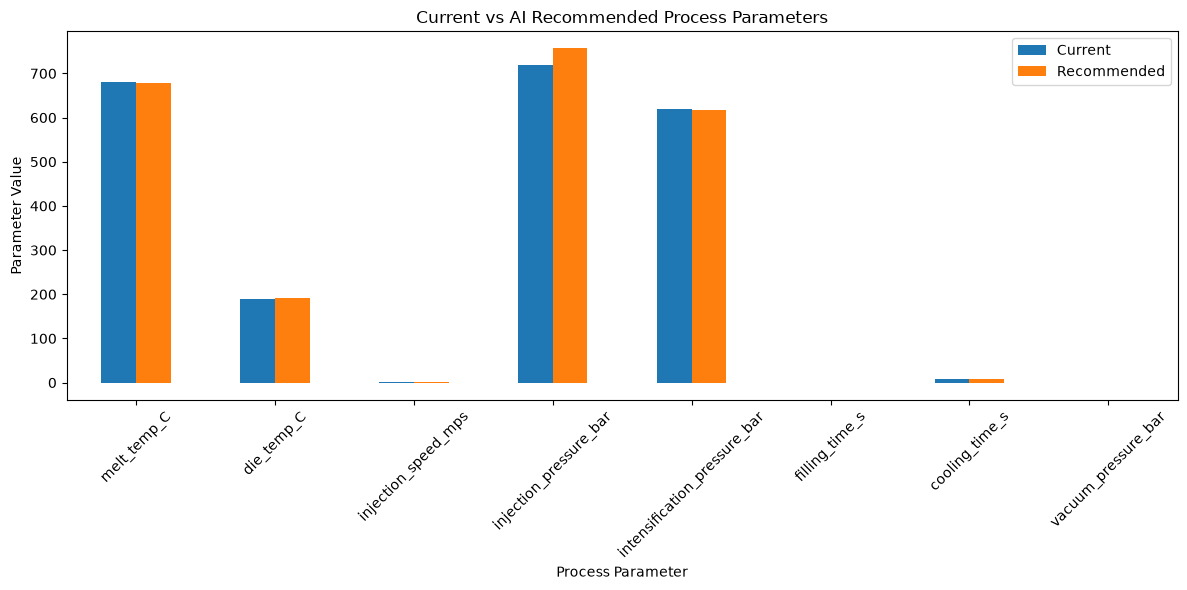

In [81]:
comparison_plot = comparison.copy()

comparison_plot = comparison_plot.set_index(
    "Parameter"
)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Current vs AI Recommended Process Parameters"
)

plt.ylabel("Parameter Value")
plt.xlabel("Process Parameter")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
print("\n" + "=" * 60)
print("             HPDC AI PROCESS ADVISOR")
print("=" * 60)

print(
    f"\nCurrent predicted defect risk: "
    f"{current_probability * 100:.2f}%"
)

print(
    f"Recommended predicted defect risk: "
    f"{best['defect_probability'] * 100:.2f}%"
)

risk_reduction = (
    current_probability - best["defect_probability"]
) * 100

print(
    f"Potential predicted risk reduction: "
    f"{risk_reduction:.2f} percentage points"
)

print("\nRecommended changes:")

for parameter in parameter_ranges.keys():
    
    current_value = current_process[parameter]
    recommended_value = best[parameter]
    
    difference = recommended_value - current_value
    
    print(
        f"• {parameter}: "
        f"{current_value:.3f} → "
        f"{recommended_value:.3f} "
        f"({difference:+.3f})"
    )

print("\n⚠️ Recommendation is model-based.")
print("Validate process changes before applying them")
print("to an actual production machine.")

print("=" * 60)


             HPDC AI PROCESS ADVISOR

Current predicted defect risk: 48.67%
Recommended predicted defect risk: 0.00%
Potential predicted risk reduction: 48.67 percentage points

Recommended changes:
• melt_temp_C: 680.000 → 679.357 (-0.643)
• die_temp_C: 190.000 → 192.492 (+2.492)
• injection_speed_mps: 2.500 → 2.514 (+0.014)
• injection_pressure_bar: 720.000 → 757.418 (+37.418)
• intensification_pressure_bar: 620.000 → 616.543 (-3.457)
• filling_time_s: 0.045 → 0.044 (-0.001)
• cooling_time_s: 8.500 → 8.279 (-0.221)
• vacuum_pressure_bar: -0.750 → -0.801 (-0.051)

⚠️ Recommendation is model-based.
Validate process changes before applying them
to an actual production machine.
